In [193]:
# x1,y1,x2,y2
box_a = [3, 3, 6, 6]
box_b = [4, 4, 7, 7]

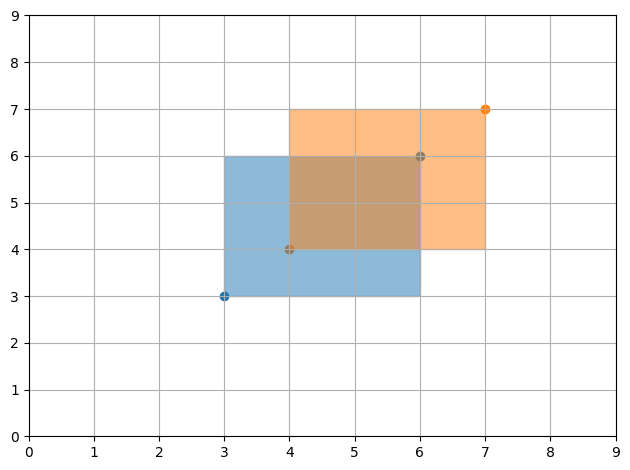

In [194]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import numpy as np

plt.scatter(box_a[::2], box_a[1::2])
plt.scatter(box_b[::2], box_b[1::2])

plt.gca().add_patch(
    patches.Rectangle(
        (box_a[:2]), box_a[2] - box_a[0], box_a[3] - box_a[1], color="tab:blue", alpha=0.5
    )
)
plt.gca().add_patch(
    patches.Rectangle(
        (box_b[:2]), box_b[2] - box_b[0], box_b[3] - box_b[1], color="tab:orange", alpha=0.5
    )
)

plt.grid()
plt.xticks(np.arange(0, 10, 1))
plt.yticks(np.arange(0, 10, 1))
plt.tight_layout()
plt.show()

In [195]:
box_a_area = (box_a[2] - box_a[0]) * (box_a[3] - box_a[1])
box_b_area = (box_b[2] - box_b[0]) * (box_b[3] - box_b[1])
print(box_a_area, box_b_area) # 9 9

9 9


In [ ]:
inter_x1 = max(box_a[0], box_b[0])
inter_y1 = max(box_a[1], box_b[1])
inter_x2 = min(box_a[2], box_b[2])
inter_y2 = min(box_a[3], box_b[3])

inter_w = max(0, inter_x2 - inter_x1)
inter_h = max(0, inter_y2 - inter_y1)

inter_area = inter_w * inter_h
print(inter_area) # 4

4


In [ ]:
iou = inter_area / (box_a_area + box_b_area - inter_area) # 4 / (9 + 9 - 4)
print(iou) # 0.2857142857142857

0.2857142857142857


In [ ]:
import torch

In [ ]:
import torch

box_a = torch.tensor(
    [
        [0, 0, 5, 5],
        [8, 8, 10, 10],
    ],
    dtype=torch.float32,
)

box_b = torch.tensor(
    [
        [0, 2, 1, 6],
        [2, 2, 6, 4],
        [9, 9, 11, 11],
    ],
    dtype=torch.float32,
)

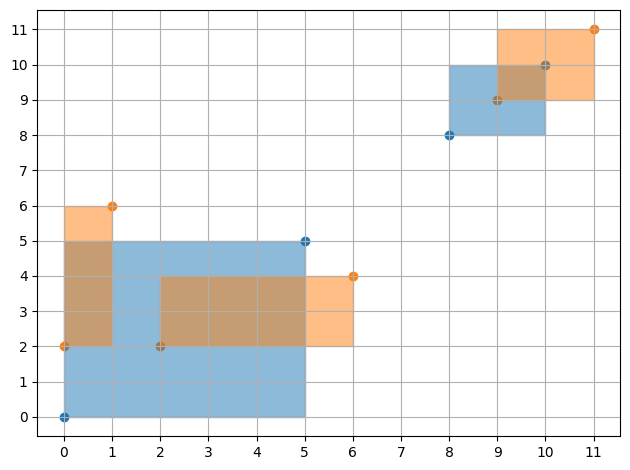

In [171]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import numpy as np

plt.scatter(box_a[:,::2], box_a[:,1::2])
plt.scatter(box_b[:,::2], box_b[:,1::2])

for box in box_a:
    plt.gca().add_patch(
        patches.Rectangle(
            (box[:2]), box[2] - box[0], box[3] - box[1], color="tab:blue", alpha=0.5
        )
    )

for box in box_b:
    plt.gca().add_patch(
        patches.Rectangle(
            (box[:2]), box[2] - box[0], box[3] - box[1], color="tab:orange", alpha=0.5
        )
    )

plt.grid()
plt.xticks(np.arange(0, 12, 1))
plt.yticks(np.arange(0, 12, 1))
plt.tight_layout()
plt.show()

In [ ]:
box_a_area = (box_a[:, 2] - box_a[:, 0]) * (box_a[:, 3] - box_a[:, 1])
box_b_area = (box_b[:, 2] - box_b[:, 0]) * (box_b[:, 3] - box_b[:, 1])

print(box_a_area, box_b_area) # tensor([25.,  4.]) tensor([4., 8., 4.])

tensor([25.,  4.]) tensor([4., 8., 4.])


In [ ]:
inter_x1 = torch.max(box_a[:,0], box_b[:,0])
inter_x1

RuntimeError: The size of tensor a (2) must match the size of tensor b (3) at non-singleton dimension 0

In [ ]:
inter_x1 = torch.max(box_a[:, 0].unsqueeze(1), box_b[:, 0].unsqueeze(0))
print(inter_x1) # tensor([[0., 2., 9.],
                # [8., 8., 9.]])

inter_y1 = torch.max(box_a[:, 1].unsqueeze(1), box_b[:, 1].unsqueeze(0))
print(inter_y1) # tensor([[2., 2., 9.],
                #[8., 8., 9.]])

inter_x2 = torch.min(box_a[:, 2].unsqueeze(1), box_b[:, 2].unsqueeze(0))
print(inter_x2) # tensor([[ 1.,  5.,  5.],
                # [ 1.,  6., 10.]])

inter_y2 = torch.min(box_a[:, 3].unsqueeze(1), box_b[:, 3].unsqueeze(0))
print(inter_y2) # tensor([[ 5.,  4.,  5.],
                # [ 6.,  4., 10.]])

tensor([[0., 2., 9.],
        [8., 8., 9.]])
tensor([[2., 2., 9.],
        [8., 8., 9.]])
tensor([[ 1.,  5.,  5.],
        [ 1.,  6., 10.]])
tensor([[ 5.,  4.,  5.],
        [ 6.,  4., 10.]])


In [ ]:
print(box_a.unsqueeze(1).shape) # torch.Size([2, 1, 4])
print(box_b.unsqueeze(0).shape) # torch.Size([1, 3, 4])

torch.Size([2, 1, 4])
torch.Size([1, 3, 4])


In [ ]:
inter_w = (inter_x2 - inter_x1).clamp(min=0)
inter_h = (inter_y2 - inter_y1).clamp(min=0)
inter_area = inter_w * inter_h

print(inter_w) # tensor([[1., 3., 0.], [0., 0., 1.]])
print(inter_h) # tensor([[3., 2., 0.], [0., 0., 1.]])
print(inter_area) # tensor([[3., 6., 0.], [0., 0., 1.]])

tensor([[1., 3., 0.],
        [0., 0., 1.]])
tensor([[3., 2., 0.],
        [0., 0., 1.]])
tensor([[3., 6., 0.],
        [0., 0., 1.]])
tensor([[29., 33., 29.],
        [ 8., 12.,  8.]])


In [ ]:
ious = inter_area / (box_a_area.unsqueeze(1) + box_b_area.unsqueeze(0) - inter_area)
ious # tensor([[0.1154, 0.2222, 0.0000], [0.0000, 0.0000, 0.1429]])

tensor([[0.1154, 0.2222, 0.0000],
        [0.0000, 0.0000, 0.1429]])